# AutoSort Training Pipeline

Main steps:
1. Threshold detection
2. Training data preparation
3. Model training


In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface.core import concatenate_recordings
from probeinterface import write_probeinterface, read_probeinterface

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils_clique import (
    prepare_training_data,
    train_autosort_model,
    CliqueInfo,
    plot_cliques
)
import torch
import gc

In [2]:
channel_list_A = ['A-000', 'A-001', 'A-002',
       'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
       'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-016',
       'A-017', 'A-018', 'A-019', 'A-020', 'A-021', 'A-022', 'A-023',
       'A-024', 'A-025', 'A-026', 'A-027', 'A-028', 'A-029', 'A-030',
       'A-031', 'A-032', 'A-033', 'A-034', 'A-035', 'A-036', 'A-037',
       'A-038', 'A-039', 'A-040', 'A-041', 'A-042', 'A-043', 'A-044',
       'A-045', 'A-046', 'A-047', 'A-048', 'A-049', 'A-050', 'A-051',
       'A-052', 'A-053', 'A-054', 'A-055', 'A-056', 'A-057', 'A-058',
       'A-059', 'A-060', 'A-061', 'A-062', 'A-063', 'A-064', 'A-065',
       'A-066', 'A-067', 'A-068', 'A-069', 'A-070', 'A-071', 'A-072',
       'A-073', 'A-074', 'A-075', 'A-076', 'A-077', 'A-078', 'A-079',
       'A-080', 'A-081', 'A-082', 'A-083', 'A-084', 'A-085', 'A-086',
       'A-087', 'A-088', 'A-089', 'A-090', 'A-091', 'A-092', 'A-093',
       'A-094', 'A-095', 'A-096', 'A-097', 'A-098', 'A-099', 'A-100',
       'A-101', 'A-102', 'A-103', 'A-104', 'A-105', 'A-106', 'A-107',
       'A-108', 'A-109', 'A-110', 'A-111', 'A-112', 'A-113', 'A-114',
       'A-115', 'A-116', 'A-117', 'A-118', 'A-119', 'A-120', 'A-121',
       'A-122', 'A-123', 'A-124', 'A-125', 'A-126', 'A-127']

In [3]:
spike_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl"

recording_path = Path(f"/media/ubuntu/sda/mouse_test/raw_data/WLF_128ch2mouse1_natima_251217_225054")
rhd_files = list(recording_path.glob("*.rhd"))

file_list = sorted(rhd_files)
recording_raw_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(file, stream_id= '0'))
recording_raw = concatenate_recordings(recording_list=recording_raw_list)




In [4]:
recording_raw = recording_raw.select_channels(channel_list_A)
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [5]:
probe = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/tip_probe_128_1.json')
if probe is None:
    raise ValueError("Recording does not have probe information")

# 定义按shank构建cliques的函数
def build_shank_cliques(probe, shank_boundaries=[250, 750, 1250]):
    """
    根据x坐标划分shank并构建cliques
    
    Parameters:
        probe: Probe对象
        shank_boundaries: shank之间的x坐标边界，默认[250, 750, 1250]
                         将probe划分为4个shank:
                         - shank 0: x < 250
                         - shank 1: 250 <= x < 750
                         - shank 2: 750 <= x < 1250
                         - shank 3: x >= 1250
    
    Returns:
        cliques: List[CliqueInfo] - 每个shank对应一个clique
    """
    from typing import List
    
    df = probe.to_dataframe()
    if "device_channel_indices" in df.columns:
        device_indices = df["device_channel_indices"].astype(int).to_numpy()
    else:
        device_indices = np.arange(len(df), dtype=int)
    positions = df.loc[:, ["x", "y"]].to_numpy()
    contact_ids = df["contact_ids"].astype(str).to_numpy()
    
    # 根据x坐标划分shank
    x_coords = positions[:, 0]
    shank_boundaries_sorted = sorted(shank_boundaries)
    
    cliques: List[CliqueInfo] = []
    
    # 定义shank范围
    shank_ranges = [
        (float('-inf'), shank_boundaries_sorted[0]),  # shank 0: x < 250
        (shank_boundaries_sorted[0], shank_boundaries_sorted[1]),  # shank 1: 250 <= x < 750
        (shank_boundaries_sorted[1], shank_boundaries_sorted[2]),  # shank 2: 750 <= x < 1250
        (shank_boundaries_sorted[2], float('inf')),  # shank 3: x >= 1250
    ]
    
    for shank_id, (x_min, x_max) in enumerate(shank_ranges):
        # 找到属于当前shank的通道
        if x_min == float('-inf'):
            mask = x_coords < x_max
        elif x_max == float('inf'):
            mask = x_coords >= x_min
        else:
            mask = (x_coords >= x_min) & (x_coords < x_max)
        
        shank_device_indices = device_indices[mask]
        shank_contact_ids = contact_ids[mask]
        shank_positions = positions[mask]
        
        if len(shank_device_indices) == 0:
            print(f"[WARNING] Shank {shank_id} has no channels")
            continue
        
        # 计算shank的中心位置
        center = tuple(np.mean(shank_positions, axis=0))
        
        # 创建CliqueInfo对象
        clique = CliqueInfo(
            clique_id=shank_id,
            device_channel_indices=list(shank_device_indices),
            contact_ids=list(shank_contact_ids),
            center=center,
        )
        cliques.append(clique)
        
        print(f"[INFO] Shank {shank_id}: {len(shank_device_indices)} channels "
              f"(x range: {x_min if x_min != float('-inf') else 'min'} to "
              f"{x_max if x_max != float('inf') else 'max'})")
    
    print(f"[INFO] Built {len(cliques)} cliques from {len(shank_boundaries) + 1} shanks")
    return cliques

# Build cliques from probe by shank
cliques = build_shank_cliques(probe, shank_boundaries=[250, 750, 1250])

# Plot cliques visualization
output_dir = Path("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output")
output_dir.mkdir(parents=True, exist_ok=True)
plot_cliques(probe, cliques, output_pdf_path=str(output_dir / "cliques_visualization.pdf"))

# Save clique information for evaluation
clique_info = {
    'cliques': cliques,  # List of CliqueInfo objects
    'clique_params': {
        'method': 'shank_based',
        'shank_boundaries': [250, 750, 1250],
        'num_shanks': 4,
    },
    'probe_df': probe.to_dataframe(),  # Probe dataframe for verification
    'recording_path': recording_path,  # Recording path for reference
}

clique_info_path = output_dir / "clique_info.pkl"
with open(clique_info_path, 'wb') as f:
    pickle.dump(clique_info, f)

[INFO] Shank 0: 32 channels (x range: min to 250)
[INFO] Shank 1: 32 channels (x range: 250 to 750)
[INFO] Shank 2: 32 channels (x range: 750 to 1250)
[INFO] Shank 3: 32 channels (x range: 1250 to max)
[INFO] Built 4 cliques from 4 shanks

Clique可视化PDF已保存至: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/cliques_visualization.pdf


In [6]:

spike_inf = None
neuron_inf = None

if Path(spike_inf_path).exists():
    spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
else:
    raise ValueError(f"spike_inf not found at {spike_inf_path}")

if Path(neuron_inf_path).exists():
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
else:
    raise ValueError(f"neuron_inf.pkl not found at {neuron_inf_path}")

In [7]:
# Convert spike_inf time indices from 20k to 10k sampling rate
# Since recording has been downsampled from 20k to 10k, spike_inf time indices need to be divided by 2
if spike_inf is not None and 'time' in spike_inf.columns:
    print(f"Converting spike_inf time indices from 20k to 10k sampling rate...")
    print(f"  Original time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    spike_inf['time'] = spike_inf['time'] / 2.0
    spike_inf['time'] = spike_inf['time'].astype(int)  # Convert to integer
    print(f"  Converted time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    print(f"  Total spikes: {len(spike_inf)}")
else:
    print("Warning: spike_inf is None or does not have 'time' column")


Converting spike_inf time indices from 20k to 10k sampling rate...
  Original time range: 45 - 26619805
  Converted time range: 22 - 13309902
  Total spikes: 1256663


In [ ]:
# Set parameters
from typing import Any


base_save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output"
duration_seconds = 500 

# Check if required data is loaded
if spike_inf is None:
    raise ValueError("spike_inf is required but not loaded")
if neuron_inf is None:
    raise ValueError("neuron_inf is required but not loaded")

# MountainSort4 detection parameters
mountainsort4_params = {
    'detect_threshold': 2,     
    'detect_interval': 10,      
    'detect_sign': -1,          
    'margin': 0,               
    'apply_bandpass_filter': True,  
    'freq_min': 300,            
    'freq_max': 3000,          
}

window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

whitening_params = {
    'apply_whitening': True,
}

all_train_data_dirs = {}


recording_channel_ids = recording_f.get_channel_ids()  
probe_df = probe.to_dataframe()
if "device_channel_indices" in probe_df.columns:
    probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
else:
    probe_device_indices = np.arange(len(probe_df), dtype=int)

device_to_recording_channel = {}
for i, device_idx in enumerate(probe_device_indices):
    if i < len(recording_channel_ids):
        device_to_recording_channel[device_idx] = recording_channel_ids[i]


for clique_id, clique in enumerate(cliques):
    save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    clique_device_indices = set(clique.device_channel_indices)
    

    sorted_device_indices = sorted(clique_device_indices)
    clique_channel_ids = [device_to_recording_channel[idx] for idx in sorted_device_indices if idx in device_to_recording_channel]
    recording_clique = recording_f.select_channels(channel_ids=clique_channel_ids)
    

    recording_clique = recording_clique.rename_channels(sorted_device_indices)
    
    clique_channels = clique_device_indices
    
    neuron_ids_in_clique = []
    for idx, row in neuron_inf.iterrows():
        channels = row.get('channel_id', [])
        if isinstance(channels, str):
            import ast
            try:
                channels = ast.literal_eval(channels)
            except:
                channels = []
        channels_set = set[Any](channels)
        if len(channels_set) > 0 and channels_set.issubset(clique_channels):
            neuron_ids_in_clique.append(row['Neuron'])
    
    neuron_inf_clique = neuron_inf[neuron_inf['Neuron'].isin(neuron_ids_in_clique)].copy()
    spike_inf_clique = spike_inf[spike_inf['neuron'].isin(neuron_ids_in_clique)].copy()
    

    train_data_dir = prepare_training_data(
        recording_f=recording_clique,  
        spike_inf=spike_inf_clique,
        neuron_inf=neuron_inf_clique,
        save_dir=str(save_dir),
        duration_seconds=duration_seconds,
        **mountainsort4_params,
        **window_params,
        **whitening_params  
    )
    
    all_train_data_dirs[clique_id] = train_data_dir


### 1. Threshold Detection
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)

[INFO] 应用Mountainsort4预处理流程（与evaluate_mountainsort4_detection.py保持一致）
  截取前 500 秒数据: 5000000 samples
  应用bandpass filter...
    频率范围: 300 - 3000 Hz
  应用whiten预处理（用于阈值检测和waveform提取）...
    使用默认的random_chunk_kwargs（每个segment采样20个chunks）
Original data shape: (5000000, 32) (clique channels, 已截取，用于waveform提取)
[INFO] 加载已保存的白化矩阵...
  白化矩阵形状: (32, 32)
  均值向量形状: (1, 32)
[INFO] 白化预处理完成
    白化完成（用于阈值检测）
Whitened data shape: (5000000, 32) (clique channels, 已截取，用于检测)

### 1.1. Compute valid_channels from channel_id
Valid channels (union of all channel_id): [1, 2, 4, 6, 7, 13, 14, 17, 19, 25, 27, 28, 31] (共 13 个通道)

[INFO] 使用 MountainSort4 检测方法
  阈值: 2, 间隔: 10, 检测方向: -1, 边界margin: 0
  仅在以下通道上进行检测: [1, 2, 4, 6, 7, 13, 14, 17, 19, 25, 27, 28, 31] (共 13 个通道)
  注意：检测使用白化数据，waveform提取使用原始数据
Building detect_array...
Num

Extracting waveforms: 100%|██████████| 30/30 [00:12<00:00,  2.48it/s]


Waveform extraction completed!
waveform shape: (1023089, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/train_data
Data statistics:
  - Total spike count: 1023089
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 4
  - Noise spike count: 997148
  - Valid spike count: 25941
### 1. Threshold Detection
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)

[INFO] 应用Mountainsort4预处理流程（与evaluate_mountainsort4_dete

Extracting waveforms: 100%|██████████| 30/30 [00:16<00:00,  1.85it/s]


Waveform extraction completed!
waveform shape: (1371361, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_01/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_01/train_data
Data statistics:
  - Total spike count: 1371361
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 6
  - Noise spike count: 1312090
  - Valid spike count: 59271
### 1. Threshold Detection
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)

[INFO] 应用Mountainsort4预处理流程（与evaluate_mountainsort4_det

Extracting waveforms: 100%|██████████| 30/30 [00:25<00:00,  1.18it/s]


Waveform extraction completed!
waveform shape: (2116929, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_02/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_02/train_data
Data statistics:
  - Total spike count: 2116929
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 17
  - Noise spike count: 1893773
  - Valid spike count: 223156
### 1. Threshold Detection
Sampling rate: 10000.0 Hz, Number of channels: 32
Recording total length: 13309952 samples (1331.00 seconds)
Will process first 5000000 samples (500.00 seconds)

[INFO] 应用Mountainsort4预处理流程（与evaluate_mountainsort4_d

Extracting waveforms: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


Waveform extraction completed!
waveform shape: (1955841, 32, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/train_data
Data statistics:
  - Total spike count: 1955841
  - Number of channels: 32
  - Window length: 30
  - Number of unique units: 15
  - Noise spike count: 1821574
  - Valid spike count: 134267


## Step 2: Model Training


In [9]:
# Set training parameters
training_params = {
    'epochs': 20,
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
    'early_stopping': True,  # Enable early stopping
    'patience': 5,  # Stop if accuracy doesn't improve for 5 consecutive epochs
    'min_delta': 0.0,  # Minimum change
}

# Repeat training 5 times per clique
n_runs = 1

# Train models for each clique
all_models_dict = {}
all_logs_dict = {}

for clique_id, clique in enumerate(cliques):
    if clique_id not in all_train_data_dirs:
        print(f"Skipping clique {clique_id} (no training data)")
        continue
    
    print(f"\n{'='*80}")
    print(f"Training models for Clique {clique_id:02d}")
    print(f"{'='*80}")
    
    train_data_dir = all_train_data_dirs[clique_id]
    base_model_save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "model_save"
    
    # Get number of channels for this clique
    n_channels = len(clique.device_channel_indices)
    
    all_models = []
    all_logs = []
    
    for run_id in range(1, n_runs + 1):
        print(f"\n{'-'*60}")
        print(f"Clique {clique_id:02d} - Training run {run_id}/{n_runs}")
        print(f"{'-'*60}")
        
        # Create independent save directory for each training run
        model_save_dir = base_model_save_dir / f"run_{run_id}"
        model_save_dir.mkdir(parents=True, exist_ok=True)
        
        # Train model
        autosort_model, training_log = train_autosort_model(
            train_data_dir=train_data_dir,
            model_save_dir=str(model_save_dir),
            n_channels=n_channels,
            **training_params
        )
        
        all_models.append(autosort_model)
        all_logs.append(training_log)
        
        print(f"Clique {clique_id:02d} - Run {run_id} completed!")
        print(f"Model save directory: {model_save_dir}")
    
    all_models_dict[clique_id] = all_models
    all_logs_dict[clique_id] = all_logs
    gc.collect()
    torch.cuda.empty_cache()
    print(f"\nClique {clique_id:02d} - All {n_runs} training runs completed!")

print(f"\n{'='*80}")
print(f"All cliques training completed!")
print(f"{'='*80}")



Training models for Clique 00

------------------------------------------------------------
Clique 00 - Training run 1/1
------------------------------------------------------------
Using device: cuda
Create dataset...
Model parameters:
  - Number of channels: 32
  - Window length: 30
  - Number of units: 4
  - Input dimension: 990
Unit ID list saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/model_save/run_1/keep_id.pkl
Saved train/val split indices to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_00/model_save/run_1/train_val_split_indices.pkl

Dataset split:
  - Training set: 818471 samples
  - Validation set: 204618 samples

Starting training (total 20 epochs)...
Early stopping enabled: patience=5, min_delta=0.0
epoch : 1/20


Training: 100%|██████████| 1599/1599 [00:11<00:00, 134.17it/s]


epoch : 1/20, detection loss = 366.022134, classification loss = 478.949761


Validation: 100%|██████████| 400/400 [00:01<00:00, 219.62it/s]


epoch : 1/20, val detection loss = 261.551381, classification loss = 228.800731
Validation Loss Decreased(inf--->490.352113)
Validation Accuracy Decreased(inf--->0.876995) 	 Saving The Model (Best Acc Epoch)
epoch : 2/20


...

epoch : 5/20, val detection loss = 300.242523, classification loss = 191.134062
Validation Loss Decreased(494.633968--->491.376584)
epoch : 6/20


Training: 100%|██████████| 3056/3056 [00:22<00:00, 134.18it/s]


epoch : 6/20, detection loss = 247.148256, classification loss = 172.923689


Validation: 100%|██████████| 765/765 [00:03<00:00, 220.26it/s]


epoch : 6/20, val detection loss = 297.174112, classification loss = 184.128047
Validation Loss Decreased(491.376584--->481.302159)

Early stopping triggered: 5 consecutive epochs without improvement
Best accuracy: 0.830932 (Epoch 1)

Saving final model (epoch 20) for evaluation...

Training completed! Training log saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/model_save/run_1/training_log.csv
Best validation accuracy: 0.830932 (Epoch 1)
Clique 03 - Run 1 completed!
Model save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_03/model_save/run_1

Clique 03 - All 1 training runs completed!

All cliques training completed!


Loading model from: output/clique_03/model_save/run_1
Loading data from: output/clique_03/train_data
Validation set size: 391169
Model loaded successfully

Extracting embeddings...
Detection embeddings shape: (391169, 30)
Classification embeddings shape: (391169, 30)

Applying UMAP...
UMAP transformation completed

Plotting detection model embeddings...
Figure saved to: output/clique_03/model_save/run_1/umap_detection.png


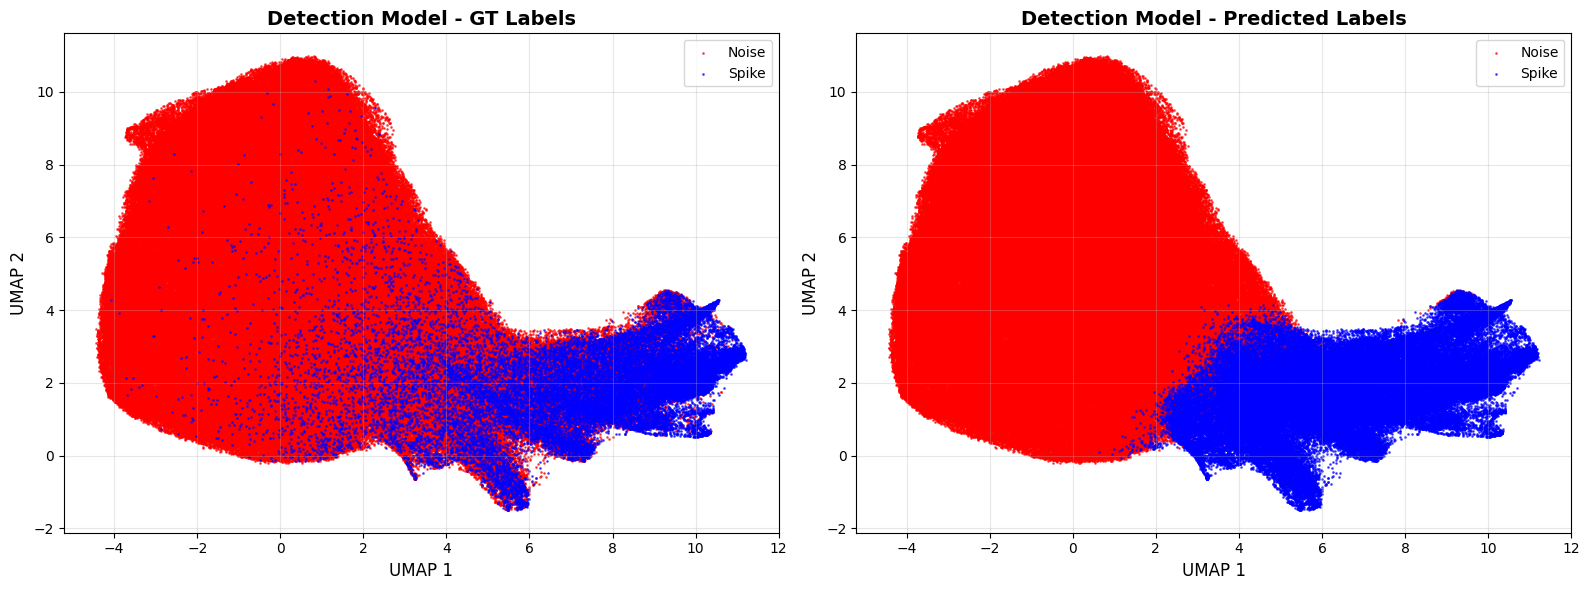


Plotting classification model embeddings...
Figure saved to: output/clique_03/model_save/run_1/umap_classification.png


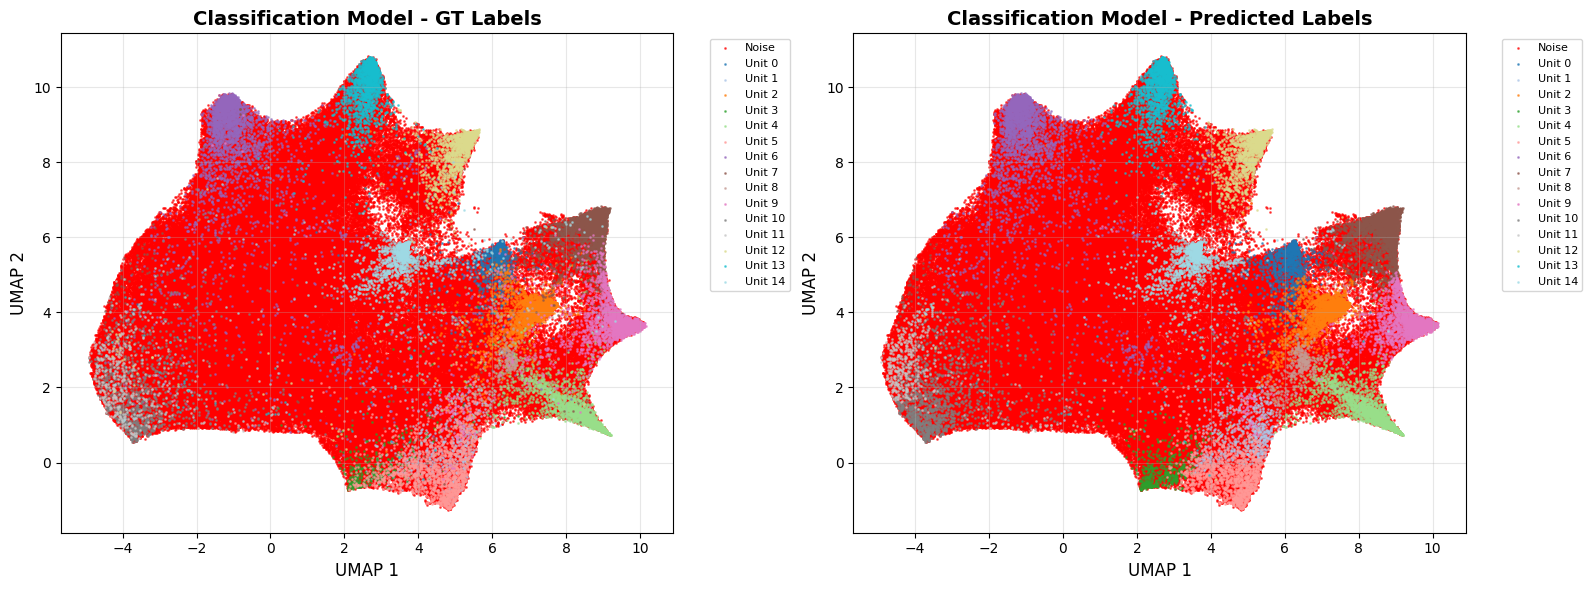


Visualization completed!


In [10]:
# Extract way4 embeddings from detection and classification models and visualize with UMAP

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from umap import UMAP
from sklearn.preprocessing import LabelEncoder
from utils_clique import SimpleAutoSort, SimpleWaveformLoader

# Parameters
clique_id =3
run_id = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
base_save_dir = Path("output")
model_save_dir = base_save_dir / f"clique_{clique_id:02d}" / "model_save" / f"run_{run_id}"
train_data_dir = base_save_dir / f"clique_{clique_id:02d}" / "train_data"

print(f"Loading model from: {model_save_dir}")
print(f"Loading data from: {train_data_dir}")

# Load dataset
dataset = SimpleWaveformLoader(root=str(train_data_dir) + "/", shank_channel=None)
n_channels = dataset.Img.shape[1]
samplepoints = dataset.Img.shape[2]

# Load train/val split indices
train_val_split_path = model_save_dir / "train_val_split_indices.pkl"
if train_val_split_path.exists():
    with open(train_val_split_path, "rb") as f:
        train_indices, val_indices = pickle.load(f)
    val_dataset = torch.utils.data.Subset(dataset, val_indices)
    print(f"Validation set size: {len(val_indices)}")
else:
    raise FileNotFoundError(f"Train/val split indices not found at {train_val_split_path}")

# Create model
autosort_model = SimpleAutoSort(
    ch_num=n_channels,
    samplepoints=samplepoints,
    device=device,
    set_shank_id=dataset.keep_id,
    save_dir=str(model_save_dir),
    pos_weight_noise=dataset.pos_weight_noise.to(device),
    pos_weight_label=dataset.pos_weight_label.to(device)
)

# Load model weights
autosort_model.load_model()
autosort_model.eval()
print("Model loaded successfully")

# Create data loader
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1024, shuffle=False, drop_last=False)

# Extract embeddings and labels
print("\nExtracting embeddings...")
detection_embeddings = []
classification_embeddings = []
gt_noise_labels = []
pred_noise_labels = []
gt_unit_labels = []
pred_unit_labels = []

with torch.no_grad():
    for batch_idx, (batch_features, classify_labels, labels, single_waveform) in enumerate(val_loader):
        batch_features = batch_features.reshape(batch_features.shape[0], -1).to(device)
        single_waveform = single_waveform.to(device)
        labels = labels.to(device)
        classify_labels = classify_labels.to(device)
        
        # Concatenate features (waveform + single)
        codes = torch.cat((batch_features, single_waveform), axis=1)
        
        # Extract way4 embeddings from detection model (clsfier_noise)
        detection_emb = autosort_model.clsfier_noise.intermediate_forward(codes.float())
        detection_embeddings.append(detection_emb.detach().cpu().numpy())
        
        # Extract way4 embeddings from classification model (clsfier_label)
        classification_emb = autosort_model.clsfier_label.intermediate_forward(codes.float())
        classification_embeddings.append(classification_emb.detach().cpu().numpy())
        
        # Get predictions
        noise_output = autosort_model.clsfier_noise(codes.float())
        pred_noise = torch.argmax(noise_output, dim=1)
        gt_noise = torch.argmax(labels, dim=1)
        
        gt_noise_labels.append(gt_noise.detach().cpu().numpy())
        pred_noise_labels.append(pred_noise.detach().cpu().numpy())
        
        # Unit labels (only for non-noise samples)
        test = labels[:, 1] == 1
        if sum(test) > 0:
            unit_output = autosort_model.clsfier_label(codes.float()[test, :])
            pred_unit = torch.argmax(unit_output, dim=1)
            gt_unit = torch.argmax(classify_labels[test, :len(autosort_model.set_shank_id)], dim=1)
            
            # Create full arrays (with -1 for noise samples)
            full_pred_unit = np.full(len(test), -1, dtype=int)
            full_gt_unit = np.full(len(test), -1, dtype=int)
            full_pred_unit[test.cpu().numpy()] = pred_unit.cpu().numpy()
            full_gt_unit[test.cpu().numpy()] = gt_unit.cpu().numpy()
            
            pred_unit_labels.append(full_pred_unit)
            gt_unit_labels.append(full_gt_unit)
        else:
            pred_unit_labels.append(np.full(len(test), -1, dtype=int))
            gt_unit_labels.append(np.full(len(test), -1, dtype=int))

# Concatenate all embeddings and labels
detection_embeddings = np.concatenate(detection_embeddings, axis=0)
classification_embeddings = np.concatenate(classification_embeddings, axis=0)
gt_noise_labels = np.concatenate(gt_noise_labels, axis=0)
pred_noise_labels = np.concatenate(pred_noise_labels, axis=0)
gt_unit_labels = np.concatenate(gt_unit_labels, axis=0)
pred_unit_labels = np.concatenate(pred_unit_labels, axis=0)

print(f"Detection embeddings shape: {detection_embeddings.shape}")
print(f"Classification embeddings shape: {classification_embeddings.shape}")

# Apply UMAP
print("\nApplying UMAP...")
umap_detection = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_classification = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)

detection_2d = umap_detection.fit_transform(detection_embeddings)
classification_2d = umap_classification.fit_transform(classification_embeddings)

print("UMAP transformation completed")

# Create label mappings for visualization
# For noise detection: 0=noise, 1=spike
# For unit classification: use unit IDs, -1 for noise

# Plot function
def plot_umap(embeddings_2d, gt_labels, pred_labels, title, label_type="noise", save_path=None):
    """Plot UMAP visualization with labels"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    if label_type == "noise":
        # Noise detection labels: 0=noise, 1=spike
        unique_labels = np.unique(gt_labels)
        colors = ['red', 'blue']
        label_names = ['Noise', 'Spike']
        
        for i, label in enumerate(unique_labels):
            mask = gt_labels == label
            axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                          c=colors[label], alpha=0.6, s=1, label=label_names[label])
        
        axes[0].set_title(f'{title} - GT Labels', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('UMAP 1', fontsize=12)
        axes[0].set_ylabel('UMAP 2', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Predicted labels
        unique_labels_pred = np.unique(pred_labels)
        for i, label in enumerate(unique_labels_pred):
            mask = pred_labels == label
            axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                          c=colors[label], alpha=0.6, s=1, label=label_names[label])
        
        axes[1].set_title(f'{title} - Predicted Labels', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('UMAP 1', fontsize=12)
        axes[1].set_ylabel('UMAP 2', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
    else:  # unit classification
        # Unit labels: -1 for noise, unit IDs for spikes
        # GT labels
        noise_mask = gt_labels == -1
        spike_mask = ~noise_mask
        
        axes[0].scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1], 
                       c='red', alpha=0.6, s=1, label='Noise')
        
        # Use different colors for different units
        unique_units = np.unique(gt_labels[spike_mask])
        if len(unique_units) > 0:
            cmap = plt.cm.get_cmap('tab20', len(unique_units))
            for i, unit in enumerate(unique_units):
                unit_mask = (gt_labels == unit) & spike_mask
                if np.sum(unit_mask) > 0:
                    axes[0].scatter(embeddings_2d[unit_mask, 0], embeddings_2d[unit_mask, 1], 
                                  c=[cmap(i)], alpha=0.6, s=1, label=f'Unit {unit}')
        
        axes[0].set_title(f'{title} - GT Labels', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('UMAP 1', fontsize=12)
        axes[0].set_ylabel('UMAP 2', fontsize=12)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axes[0].grid(True, alpha=0.3)
        
        # Predicted labels
        noise_mask_pred = pred_labels == -1
        spike_mask_pred = ~noise_mask_pred
        
        axes[1].scatter(embeddings_2d[noise_mask_pred, 0], embeddings_2d[noise_mask_pred, 1], 
                       c='red', alpha=0.6, s=1, label='Noise')
        
        unique_units_pred = np.unique(pred_labels[spike_mask_pred])
        if len(unique_units_pred) > 0:
            cmap = plt.cm.get_cmap('tab20', max(len(unique_units_pred), 1))
            for i, unit in enumerate(unique_units_pred):
                unit_mask = (pred_labels == unit) & spike_mask_pred
                if np.sum(unit_mask) > 0:
                    axes[1].scatter(embeddings_2d[unit_mask, 0], embeddings_2d[unit_mask, 1], 
                                  c=[cmap(i % len(unique_units_pred))], alpha=0.6, s=1, label=f'Unit {unit}')
        
        axes[1].set_title(f'{title} - Predicted Labels', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('UMAP 1', fontsize=12)
        axes[1].set_ylabel('UMAP 2', fontsize=12)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.show()

# Plot detection model embeddings
print("\nPlotting detection model embeddings...")
plot_umap(detection_2d, gt_noise_labels, pred_noise_labels, "Detection Model", label_type="noise",
          save_path=model_save_dir / "umap_detection.png")

# Plot classification model embeddings
print("\nPlotting classification model embeddings...")
plot_umap(classification_2d, gt_unit_labels, pred_unit_labels, "Classification Model", label_type="unit",
          save_path=model_save_dir / "umap_classification.png")

print("\nVisualization completed!")


In [12]:
a = pd.read_csv("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_02/model_save/run_1/eval/confusion_matrix_122125.csv", index_col = 0)

<Axes: ylabel='gt_label'>

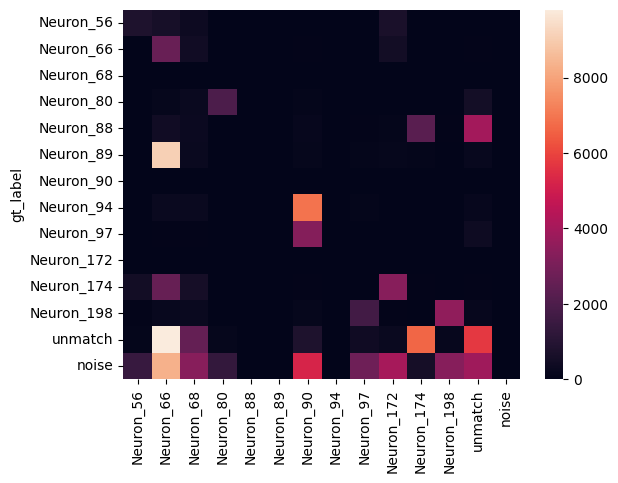

In [19]:
sns.heatmap(a.iloc[:-1, :-1])